In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier,  HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
import warnings 
import missingno as msno
import scipy.stats as stats
from scipy.stats import chi2_contingency
import keras
from keras.models import Sequential
from keras.models import Model
from keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')
# 0) Imports
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


In [2]:
features = pd.read_csv('train_values.csv')
labels = pd.read_csv('train_labels.csv')

df = pd.concat([features, labels['damage_grade']], axis=1)
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [3]:
#Splitting the data between training and testing
X_train, X_val, y_train, y_val = train_test_split(df.drop('damage_grade', axis=1), df['damage_grade'], random_state=20, shuffle=True, test_size=0.01)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(257994, 39)
(2607, 39)
(257994,)
(2607,)


In [4]:
column_names = list(df.drop('damage_grade', axis=1).columns)
multi_class_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()>2]
binary_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()==2]
num_columns = [col for col in column_names if df[col].dtype!='object']
print(f"Multi Class columns: {multi_class_columns}")
print(f"Binary columns: {binary_columns}")
print(f"Numerical columns: {num_columns}")

Multi Class columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Binary columns: []
Numerical columns: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', '

In [5]:
numeric_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='median')),  # fill missing values
    ('scale',  StandardScaler())                   # standardize features
])

In [6]:

cat_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),  # fill missing with "MISSING"
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # one-hot encode
])


In [7]:
preprocessor_simple= ColumnTransformer([
    ('num', numeric_pipeline_simple, num_columns),
    ('cat', cat_pipeline_simple, multi_class_columns + binary_columns)
])

In [8]:
# 5) Pipeline factory
def get_pipeline(model):
    """
    Returns a full Pipeline that:
     - applies preprocessor to DataFrame
     - then fits the model
    """
    return Pipeline([
        ('preprocessor', preprocessor_simple),
        ('clf',        model)
    ])

In [9]:
from sklearn.svm import LinearSVC
# Create an SVM classifier
svm_clf = LinearSVC(C=1.0, max_iter=5000, random_state=42)

pipe= get_pipeline(svm_clf)

# Fit on the training data
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'geo_level_2_id',
                                                   'geo_level_3_id',
                                                   'count_floors_pre_eq', 'age',
                                                   'area_percentage',
                                                   'height_percentage',
                                                   'has_superstructure_adobe_mud',
                                                   'has_superstructure_mud_mor...
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status'])])),
                ('clf', LinearSVC(max_iter=5000, random_state=42))])

In [10]:
# Predict on validation set
y_pred = pipe.predict(X_val)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy on validation set: 0.6003068661296509

Classification Report:
               precision    recall  f1-score   support

           1       0.64      0.26      0.37       246
           2       0.60      0.91      0.72      1490
           3       0.57      0.17      0.26       871

    accuracy                           0.60      2607
   macro avg       0.60      0.45      0.45      2607
weighted avg       0.60      0.60      0.54      2607



In [11]:
df_test = pd.read_csv('test_values.csv')

In [12]:
ids     = df_test['building_id'].values
ids

array([ 300051,   99355,  890251, ..., 1049160,  442785,  501372])

In [13]:
X_test  = df_test

In [14]:
preds = pipe.predict(X_test)
# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,          # make sure you have 'ids' variable defined
    'damage_grade': preds
}).to_csv('SimpleSVM_submission.csv', index=False)

*** Preprocessed SVM****

In [15]:
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    # get the cutoffs once
    qs = X[['area_percentage','height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    
    # clip each column
    for col in ['area_percentage','height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

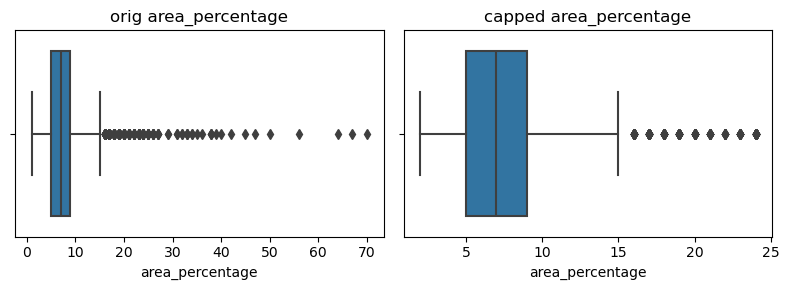

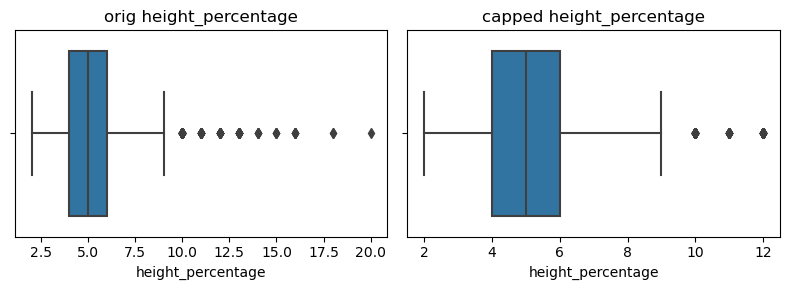

In [16]:
# apply to a small sample
sample = df[['area_percentage','height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)

import matplotlib.pyplot as plt, seaborn as sns

for col in ['area_percentage','height_percentage']:
    fig, axes = plt.subplots(1,2, figsize=(8,3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"orig {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"capped {col}")
    plt.tight_layout()
    plt.show()


In [17]:
# 1) Define our custom capper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols            # e.g. ['area_percentage','height_percentage']
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # X is a numpy array of shape (n_samples, n_num_cols)
        # find each target col’s integer index
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        # extract the sub‐array of just those columns
        sub = X[:, self.col_indices_]
        # compute quantiles along axis=0 → shape (2, len(cols))
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        # clip each specified column by its learned lo_/hi_
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

In [18]:
# 2) Numeric pipeline
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('cap',    OutlierCapper(cols=['area_percentage','height_percentage'],
                             lower=0.01, upper=0.99)),
    ('power',  PowerTransformer(method='yeo-johnson')),
    ('scale',  RobustScaler()),
])


In [19]:
# 3) Categorical pipeline
cat_pipeline = Pipeline([
    # 3a) Impute missing categories into a "MISSING" bucket
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),
    # 3b) One-hot encode all levels, ignore unseen at predict time
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [20]:
# 4) Assemble ColumnTransformer
preprocessor = ColumnTransformer([
    # apply numeric_pipeline to all numeric features
    ('num', numeric_pipeline, num_columns),
    # apply cat_pipeline to all categorical features
    ('cat', cat_pipeline,   multi_class_columns + binary_columns),
])


In [21]:
# 5) Pipeline factory
def get_pipeline(model):
    """
    Returns a full Pipeline that:
     - applies preprocessor to DataFrame
     - then fits the model
    """
    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf',        model)
    ])

In [22]:
# 7) Quick Stratified 3-fold CV to compare
cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    'acc':  'accuracy',
    'f1':   'f1',       # or 'f1_weighted', depending on your class balance
    'prec': 'precision',
    'rec':  'recall'
}

In [25]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import clone

# 1) Base model
svm = clone(LinearSVC(C=1.0, max_iter=5000, random_state=42))

# 2) Simple pipeline: preprocessing + feature selection + classifier
preprocessed_pipe = Pipeline([
    ('preproc', preprocessor),              # Preprocessing (numeric + categorical)
    ('select',  SelectKBest(score_func=f_classif)),  # Select best features
    ('clf',     svm)                         # Simple LinearSVC model
])

# 3) Fit pipeline
preprocessed_pipe.fit(X_train, y_train)

# 4) Predict on validation set
y_pred = preprocessed_pipe.predict(X_val)

# 5) Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Accuracy on validation set: 0.582662063674722

Classification Report:
               precision    recall  f1-score   support

           1       0.63      0.27      0.38       246
           2       0.58      0.98      0.73      1490
           3       0.00      0.00      0.00       871

    accuracy                           0.58      2607
   macro avg       0.40      0.41      0.37      2607
weighted avg       0.39      0.58      0.45      2607



In [26]:
# Predict on validation set
y_pred_preprocessed = preprocessed_pipe.predict(X_val)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred_preprocessed))
print("\nClassification Report:\n", classification_report(y_val, y_pred_preprocessed))

Accuracy on validation set: 0.582662063674722

Classification Report:
               precision    recall  f1-score   support

           1       0.63      0.27      0.38       246
           2       0.58      0.98      0.73      1490
           3       0.00      0.00      0.00       871

    accuracy                           0.58      2607
   macro avg       0.40      0.41      0.37      2607
weighted avg       0.39      0.58      0.45      2607



In [27]:
preds = preprocessed_pipe.predict(X_test)
# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,          # make sure you have 'ids' variable defined
    'damage_grade': preds
}).to_csv('Preprocessed_SVM_submission.csv', index=False)

**Hyperparameter Tuning**

In [28]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats import uniform, randint

# 1) Base model
svm = LinearSVC(max_iter=5000, random_state=42)

# 2) Pipeline
pipe = Pipeline([
    ('preproc', preprocessor),
    ('select',  SelectKBest(score_func=f_classif)),
    ('clf',     svm)
])

for name in pipe.get_params().keys():
    if "preproc__" in name:
        print(name)

preproc__n_jobs
preproc__remainder
preproc__sparse_threshold
preproc__transformer_weights
preproc__transformers
preproc__verbose
preproc__verbose_feature_names_out
preproc__num
preproc__cat
preproc__num__memory
preproc__num__steps
preproc__num__verbose
preproc__num__impute
preproc__num__cap
preproc__num__power
preproc__num__scale
preproc__num__impute__add_indicator
preproc__num__impute__copy
preproc__num__impute__fill_value
preproc__num__impute__keep_empty_features
preproc__num__impute__missing_values
preproc__num__impute__strategy
preproc__num__cap__cols
preproc__num__cap__lower
preproc__num__cap__upper
preproc__num__power__copy
preproc__num__power__method
preproc__num__power__standardize
preproc__num__scale__copy
preproc__num__scale__quantile_range
preproc__num__scale__unit_variance
preproc__num__scale__with_centering
preproc__num__scale__with_scaling
preproc__cat__memory
preproc__cat__steps
preproc__cat__verbose
preproc__cat__impute
preproc__cat__encode
preproc__cat__impute__add_ind

In [29]:
# 3) Parameter Search Space
param_dist = {
    # feature‐selection
    'select__k':                     randint(10, X_train.shape[1]),
    'select__score_func':            [f_classif, mutual_info_classif],

    # SVM strength
    'clf__C':                        uniform(0.001, 10.0),

    # numeric pipeline: scaling
    'preproc__num__scale__with_centering': [True, False],
    'preproc__num__scale__with_scaling':   [True, False],

    # numeric pipeline: power transform
    'preproc__num__power__method':        ['yeo-johnson', 'box-cox'],
    'preproc__num__power__standardize':   [True, False],

    # categorical pipeline: one-hot encoder
    'preproc__cat__encode__drop':         [None, 'first'],
    'preproc__cat__encode__handle_unknown':[ 'ignore', 'error' ],
    'preproc__cat__encode__sparse_output': [False, True]
}


# 4) Randomized Search (single-metric)
rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=15,
    cv=cv,
    scoring='f1_macro',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=2
)
rand_search.fit(X_train, y_train)

# 5) Fit
rand_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of 

[CV] END clf__C=2.9224464853521814, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=ignore, preproc__cat__encode__sparse_output=True, preproc__num__power__method=box-cox, preproc__num__power__standardize=True, preproc__num__scale__with_centering=False, preproc__num__scale__with_scaling=True, select__k=21, select__score_func=<function f_classif at 0x15442fd907c0>; total time=   0.9s
[CV] END clf__C=2.588799816000169, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=True, preproc__num__power__method=box-cox, preproc__num__power__standardize=False, preproc__num__scale__with_centering=False, preproc__num__scale__with_scaling=False, select__k=13, select__score_func=<function mutual_info_classif at 0x15442fd6ad40>; total time=   0.9s
[CV] END clf__C=9.219742350231167, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=False, preproc__num__powe

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END clf__C=2.9224464853521814, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=ignore, preproc__cat__encode__sparse_output=True, preproc__num__power__method=box-cox, preproc__num__power__standardize=True, preproc__num__scale__with_centering=False, preproc__num__scale__with_scaling=True, select__k=21, select__score_func=<function f_classif at 0x14e21ee207c0>; total time=   1.0s
[CV] END clf__C=2.588799816000169, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=True, preproc__num__power__method=box-cox, preproc__num__power__standardize=False, preproc__num__scale__with_centering=False, preproc__num__scale__with_scaling=False, select__k=13, select__score_func=<function mutual_info_classif at 0x14e21edfad40>; total time=   1.0s
[CV] END clf__C=9.219742350231167, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=False, preproc__num__powe

...

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni

[CV] END clf__C=9.700098521619942, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=True, preproc__num__power__method=box-cox, preproc__num__power__standardize=False, preproc__num__scale__with_centering=False, preproc__num__scale__with_scaling=True, select__k=10, select__score_func=<function mutual_info_classif at 0x150293636d40>; total time=   0.8s
[CV] END clf__C=9.489855372533333, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=True, preproc__num__power__method=box-cox, preproc__num__power__standardize=True, preproc__num__scale__with_centering=False, preproc__num__scale__with_scaling=True, select__k=11, select__score_func=<function mutual_info_classif at 0x150293636d40>; total time=   0.9s
[CV] END clf__C=0.31413292455558584, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=True, preproc__n

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END clf__C=3.746401188473625, preproc__cat__encode__drop=None, preproc__cat__encode__handle_unknown=ignore, preproc__cat__encode__sparse_output=False, preproc__num__power__method=box-cox, preproc__num__power__standardize=True, preproc__num__scale__with_centering=True, preproc__num__scale__with_scaling=True, select__k=35, select__score_func=<function f_classif at 0x1461fa0fc7c0>; total time=   0.9s
[CV] END clf__C=9.489855372533333, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=True, preproc__num__power__method=box-cox, preproc__num__power__standardize=True, preproc__num__scale__with_centering=False, preproc__num__scale__with_scaling=True, select__k=11, select__score_func=<function mutual_info_classif at 0x1461fa0d6d40>; total time=   1.0s
[CV] END clf__C=0.31413292455558584, preproc__cat__encode__drop=first, preproc__cat__encode__handle_unknown=error, preproc__cat__encode__sparse_output=True, preproc__num__power__

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preproc',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('cap',
                                                                                                OutlierCapper(cols=['area_percentage',
                                                                                                                    'height_percentage'])),
                                                                                               ('power',
                                                                                                PowerTransformer()),
                                                                                               ('scale',
                                                                                                RobustScaler())]),
                                                                               ['building_...
                                        'preproc__num__power__standardize': [True,
                                                                             False],
                                        'preproc__num__scale__with_centering': [True,
                                                                                False],
                                        'preproc__num__scale__with_scaling': [True,
                                                                              False],
                                        'select__k': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x14c7f4ed6f10>,
                                        'select__score_func': [<function f_classif at 0x14c7f6d479c0>,
                                                               <function mutual_info_classif at 0x14c7f6d45ee0>]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [31]:
# # 6) Get best scores and params
# best_idx = rand_search.best_index_
# best_wf1 = rand_search.cv_results_['mean_test_acc'][best_idx]
# best_acc = rand_search.cv_results_['mean_test_acc'][best_idx]
# best_params = rand_search.best_params_

# print(f"Best weighted_f1: {best_wf1:.4f}")
# print(f" Accuracy at that point: {best_acc:.4f}")
# print(" Best hyperparameters:")
# print(best_params)

# # 7) Log result
# records.append({
#     'Model': 'GaussianNB',
#     'Best weighted_f1': best_wf1,
#     'Accuracy at best': best_acc,
#     **{k.replace('clf__', '').replace('select__', 'select_'): v for k, v in best_params.items()}
# })


In [32]:
print("Best weighted-F1:", rand_search.best_score_)
print("Best hyperparameters:", rand_search.best_params_)

Best weighted-F1: 0.4064287751264051
Best hyperparameters: {'clf__C': 2.411254660260117, 'preproc__cat__encode__drop': 'first', 'preproc__cat__encode__handle_unknown': 'ignore', 'preproc__cat__encode__sparse_output': True, 'preproc__num__power__method': 'yeo-johnson', 'preproc__num__power__standardize': False, 'preproc__num__scale__with_centering': True, 'preproc__num__scale__with_scaling': True, 'select__k': 23, 'select__score_func': <function f_classif at 0x14c7f6d479c0>}


In [33]:
# 2) Grab the final, refit pipeline
best_svm_pipe = rand_search.best_estimator_

# 3) (Optional) Retrain explicitly on full data—though best_estimator_ is already fitted:
best_svm_pipe.fit(X_train, y_train)

# 4) Generate predictions on your test set
preds = best_svm_pipe.predict(X_test)

# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,
    'damage_grade': preds
}).to_csv('SVM_tuned_submission.csv', index=False)